#  Connexion à PostgreSQL

In [31]:
from sqlalchemy import create_engine
import pandas as pd
from dotenv import load_dotenv        # Pour charger les variables depuis le fichier .env
import os                             # Pour accéder aux variables d'environnement

# Charger les variables depuis le fichier .env
load_dotenv()

# Lire les variables d'environnement
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# Créer la connexion à la base PostgreSQL
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Préparation des données pour visualisation

Lire les tables nécessaires pour le dashboard

In [32]:

products_df= pd.read_sql("SELECT * FROM products", engine)
df_customers = pd.read_sql("SELECT * FROM customers", engine)
df_regions = pd.read_sql("SELECT * FROM regions", engine)
df_orders = pd.read_sql("SELECT * FROM orders", engine)

Vérifier la cohérence des données
Types de données corrects

In [33]:
print(df_orders.dtypes)
print(products_df.dtypes)
print(df_customers.dtypes)
print(df_regions.dtypes)

order_id         object
order_date       object
ship_date        object
ship_mode        object
year              int64
month             int64
quarter           int64
delivery_days    object
product_name     object
customer_id      object
dtype: object
id_product        int64
product_name     object
cost            float64
sales           float64
marge           float64
taux_profit     float64
sub_category     object
category         object
dtype: object
id_customer        int64
customer_id       object
customer_name     object
segment_client    object
segment           object
dtype: object
id_region       int64
postal_code    object
country        object
state          object
city           object
region_name    object
customer_id    object
dtype: object


In [34]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')
df_orders['ship_date'] = pd.to_datetime(df_orders['ship_date'], errors='coerce')


In [35]:
print(df_regions.dtypes)

id_region       int64
postal_code    object
country        object
state          object
city           object
region_name    object
customer_id    object
dtype: object


 Vérifier la complétude (valeurs manquantes)

In [36]:
print("Valeurs nulles dans orders_df :\n", df_orders.isnull().sum())
print("Valeurs nulles dans products_df :\n", products_df.isnull().sum())
print("Valeurs nulles dans customers_df :\n", df_customers.isnull().sum())
print("Valeurs nulles dans regions_df :\n", df_regions.isnull().sum())

Valeurs nulles dans orders_df :
 order_id         0
order_date       0
ship_date        0
ship_mode        0
year             0
month            0
quarter          0
delivery_days    0
product_name     0
customer_id      0
dtype: int64
Valeurs nulles dans products_df :
 id_product      0
product_name    0
cost            0
sales           0
marge           0
taux_profit     0
sub_category    0
category        0
dtype: int64
Valeurs nulles dans customers_df :
 id_customer       0
customer_id       0
customer_name     0
segment_client    0
segment           0
dtype: int64
Valeurs nulles dans regions_df :
 id_region      0
postal_code    0
country        0
state          0
city           0
region_name    0
customer_id    0
dtype: int64


## Calculer des métriques clés

Total Sales per product

In [37]:
sales_per_product = products_df.groupby('product_name')['sales'].sum().reset_index()
sales_per_product

,product_name,sales
0,"""While you Were Out"" Message Book, One Form pe...",114.268
1,"#10 Gummed Flap White Envelopes, 100/Box",289.100
2,#10 Self-Seal White Envelopes,760.774
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",2106.048
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",1639.624
...,...,...
1843,iKross Bluetooth Portable Keyboard + Cell Phon...,3343.620
1844,iOttie HLCRIO102 Car Mount,1399.300
1845,iOttie XL Car Mount,1567.216
1846,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,1662.276


Total Sales per category

In [38]:
sales_per_category = products_df.groupby('category')['sales'].sum().reset_index()
sales_per_category

,category,sales
0,Furniture,4.546582e+06
1,Office Supplies,4.106956e+06
2,Technology,5.123284e+06


Total Sales per region

In [39]:
orders_with_sales = df_orders.merge(
    products_df[['product_name','sales']], 
    on='product_name', 
    how='left'
)

sales_per_region = orders_with_sales.merge(
    df_regions[['customer_id','region_name']], 
    on='customer_id', 
    how='left'
)

sales_per_region = sales_per_region.groupby('region_name')['sales'].sum().reset_index()
sales_per_region

,region_name,sales
0,Central,2.771740e+09
1,East,3.288096e+09
2,South,1.967954e+09
3,West,3.799659e+09


Total Profit

In [40]:
total_profit = products_df['marge'].sum()
print(total_profit)

5510728.691720001


Profit Margin

In [41]:
profit_margin= (products_df['marge'].sum() / products_df['sales'].sum()) * 100
profit_margin

np.float64(40.00000000000001)

In [42]:
avg_profit_margin = profit_margin.mean()
print(f'{avg_profit_margin:.0f}')


40


Quantité vendue par catégorie

In [43]:
orders_products = df_orders.merge(
    products_df[['product_name','category']],
    on='product_name',
    how='left'
)

quantity_per_category = orders_products.groupby('category')['order_id'].count().reset_index()
quantity_per_category

,category,order_id
0,Furniture,324667
1,Office Supplies,1000146
2,Technology,228151


Calculer statistiques de base 

In [44]:
stats_sales = products_df[['sales', 'marge']].agg(['mean', 'median', 'min', 'max', 'std'])
stats_sales

,sales,marge
mean,244.001660,97.600664
median,56.314000,22.525600
min,0.444000,0.177600
max,22638.480000,9055.392000
std,673.234857,269.293943


##  Feature engineering pour visualisation

colonnes dérivées mois-année

In [45]:

df_orders['month_year'] = df_orders['order_date'].dt.to_period('M')
df_orders['month_year'] 

0        2017-11
1        2017-11
2        2017-06
3        2016-10
4        2016-10
          ...   
39127    2017-05
39128    2016-01
39129    2016-01
39130    2016-01
39131    2016-01
Name: month_year, Length: 39132, dtype: period[M]

Profit Ratio

In [46]:
products_df['profit_ratio'] = products_df['marge'] / products_df['sales']
products_df['profit_ratio'] 

0        0.4
1        0.4
2        0.4
3        0.4
4        0.4
        ... 
56457    0.4
56458    0.4
56459    0.4
56460    0.4
56461    0.4
Name: profit_ratio, Length: 56462, dtype: float64

# Agrégation des données 

Sales par mois

In [47]:
orders_products = df_orders.merge(
    products_df[['product_name','sales']],
    on='product_name',
    how='left'
)
sales_per_month = orders_products.groupby('month_year')['sales'].sum().reset_index()
sales_per_month.head()

,month_year,sales
0,2015-01,2.244573e+06
1,2015-02,7.409880e+05
2,2015-03,5.540549e+06
3,2015-04,3.668299e+06
4,2015-05,4.357983e+06


Sales par region  par période

In [48]:
df_regions.columns

Index(['id_region', 'postal_code', 'country', 'state', 'city', 'region_name',
       'customer_id'],
      dtype='object')

In [49]:
sales_region_period = (
    df_orders
    .merge(products_df[['product_name','sales']], on='product_name', how='left')
    .merge(df_regions[['customer_id','region_name']], on='customer_id', how='left')
    .groupby(['month_year','region_name'])['sales']
    .sum()
    .reset_index()
)
sales_region_period.head()

,month_year,region_name,sales
0,2015-01,Central,27330194.36
1,2015-01,East,17017206.92
2,2015-01,South,20397146.42
3,2015-01,West,19927593.70
4,2015-02,Central,5352904.34


Sales par category  par période

In [50]:
orders_products = df_orders.merge(
    products_df[['product_name','sales','category']],
    on='product_name',
    how='left'
)

sales_category_period = orders_products.groupby(
    ['month_year','category']
)['sales'].sum().reset_index()
sales_category_period.head()

,month_year,category,sales
0,2015-01,Furniture,823082.064
1,2015-01,Office Supplies,966774.732
2,2015-01,Technology,454715.744
3,2015-02,Furniture,244882.876
4,2015-02,Office Supplies,249501.448


Top 10 Produits

In [51]:
top_products = products_df.groupby('product_name')['sales'].sum() \
                          .sort_values(ascending=False) \
                          .head(10) \
                          .reset_index()

top_products

,product_name,sales
0,Canon imageCLASS 2200 Advanced Copier,431198.768
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,192173.688
2,Cisco TelePresence System EX90 Videoconferenci...,158469.360
3,HON 5400 Series Task Chairs for Big and Tall,133466.592
4,HP Designjet T520 Inkjet Large Format Printer ...,128624.265
5,GBC DocuBind P400 Electric Binding System,125755.476
6,Hewlett Packard LaserJet 3310 Copier,125157.914
7,High Speed Automatic Electric Letter Opener,119212.184
8,GBC Ibimaster 500 Manual ProClick Binding System,115060.176
9,Ibico EPK-21 Electric Binding System,111131.412


  Top 10 Clients

In [52]:
orders_products = df_orders.merge(
    products_df[['product_name','sales']],
    on='product_name',
    how='left'
)

top_clients = orders_products.groupby('customer_id')['sales'].sum() \
                             .sort_values(ascending=False) \
                             .head(10) \
                             .reset_index()

top_clients

,customer_id,sales
0,CC-12370,2.193713e+06
1,SV-20365,2.114130e+06
2,HL-15040,2.088726e+06
3,TC-20980,2.074538e+06
4,TA-21385,2.046166e+06
5,RB-19360,1.874303e+06
6,BF-11170,1.708976e+06
7,CJ-12010,1.547356e+06
8,JL-15835,1.522885e+06
9,GT-14710,1.498283e+06


##  Création des Graphiques simples

Bar chart (Sales par catégorie)

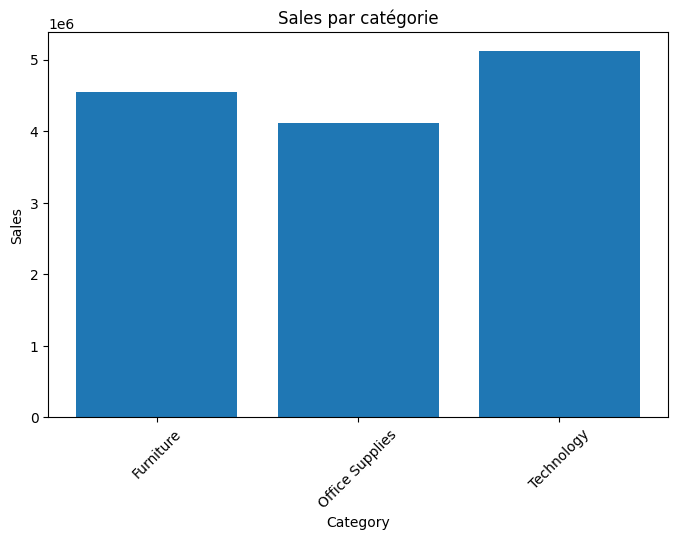

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(sales_per_category['category'], sales_per_category['sales'])
plt.title("Sales par catégorie")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Line chart (Sales par mois)

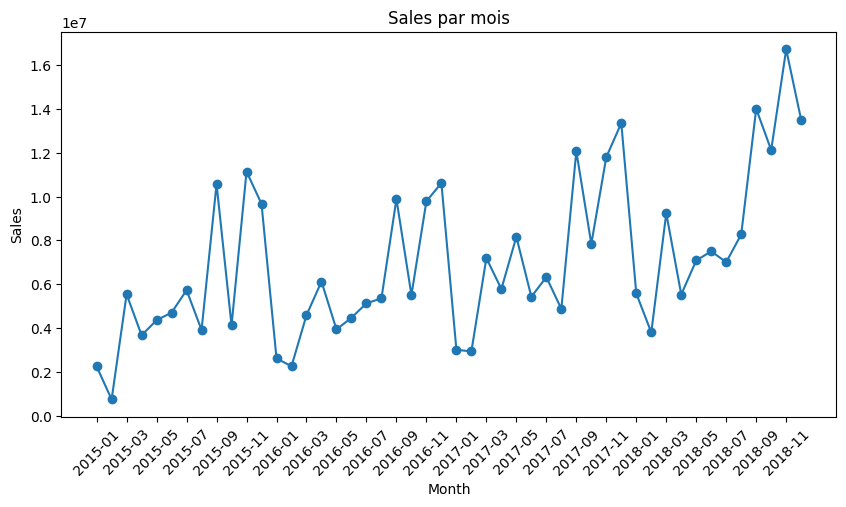

In [54]:
sales_per_month['month_year_str'] = sales_per_month['month_year'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(sales_per_month['month_year_str'], sales_per_month['sales'], marker='o')

plt.title("Sales par mois")
plt.xlabel("Month")
plt.ylabel("Sales")

# tick 
plt.xticks(sales_per_month['month_year_str'][::2], rotation=45)
plt.show()

Pie chart (Répartition des ventes par catégorie)

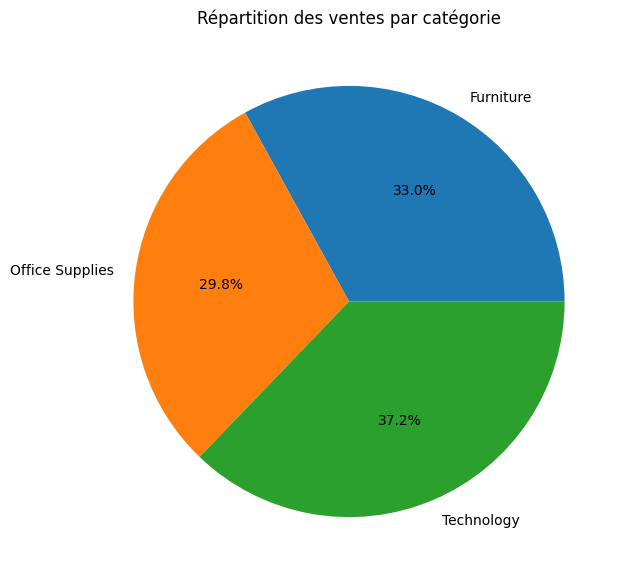

In [55]:
import matplotlib.pyplot as plt

# Créer une figure de taille 7x7 pouces
plt.figure(figsize=(7,7))

# Tracer le diagramme circulaire (Pie chart)
plt.pie(
    sales_per_category['sales'],       # Valeurs des ventes par catégorie
    labels=sales_per_category['category'],  # Noms des catégories pour chaque secteur
    autopct='%1.1f%%',                # Affiche le pourcentage de chaque secteur avec 1 décimale
                        # Commence le premier secteur à 90° (en haut)
)

# Ajouter un titre au graphique
plt.title("Répartition des ventes par catégorie")

# Afficher le graphique
plt.show()

##  Création des Graphiques combinés

Sales vs Profit

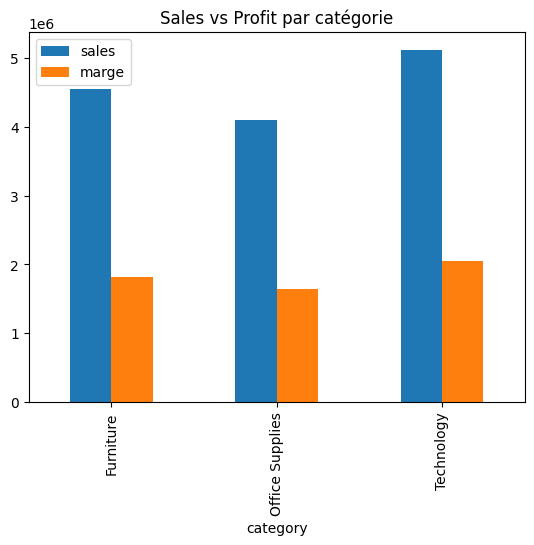

In [56]:
sales_profit = products_df.groupby('category')[['sales','marge']].sum().reset_index()

sales_profit.plot(
    x='category',
    y=['sales','marge'],
    kind='bar'
)

plt.title("Sales vs Profit par catégorie")
plt.show()

top produits

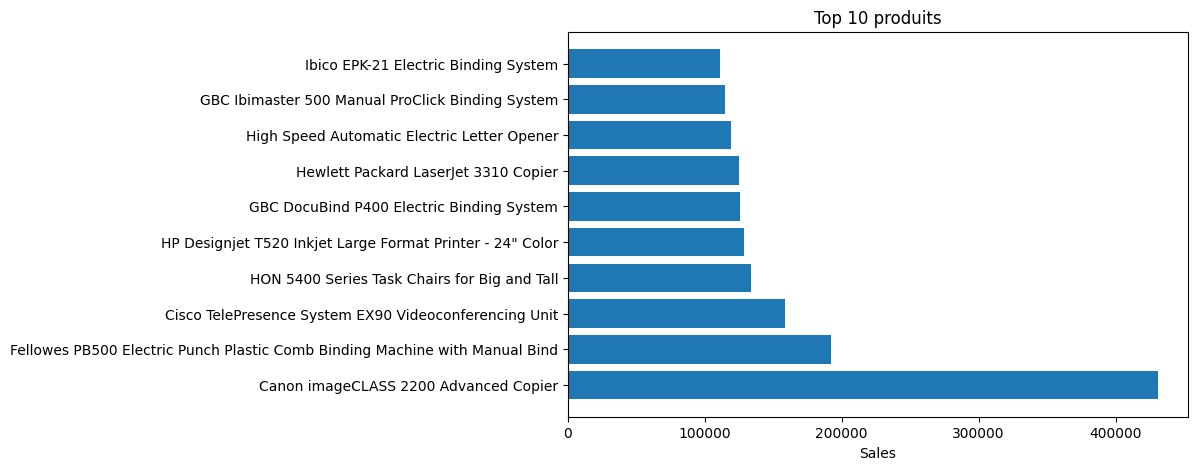

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_products['product_name'], top_products['sales'])
plt.title("Top 10 produits")
plt.xlabel("Sales")
plt.show()

Heatmap avec Seaborn

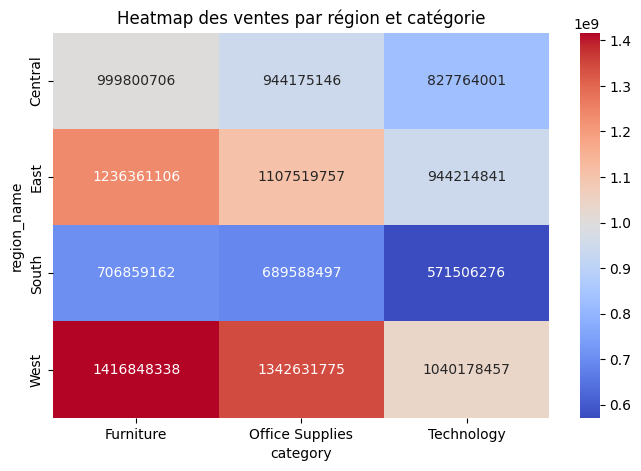

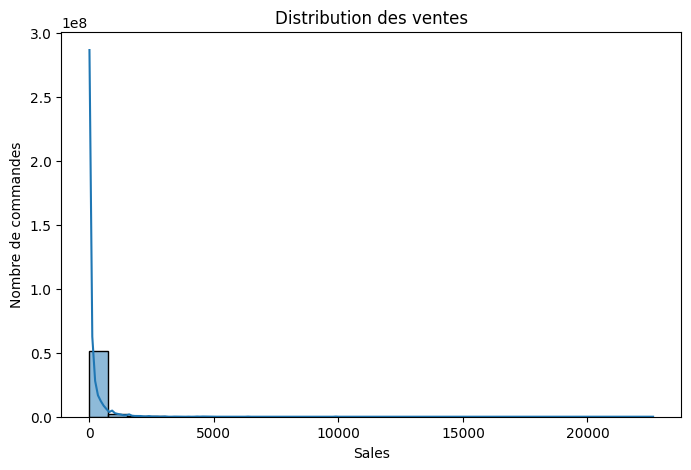

In [58]:

import matplotlib.pyplot as plt
import seaborn as sns
orders_products = df_orders.merge(
    products_df[['product_name','category','sales']],
    on='product_name',
    how='left'
)
orders_with_region = orders_products.merge(
    df_regions[['customer_id','region_name']],
    on='customer_id',
    how='left'
)

# Exemple de pivot table pour heatmap
pivot_table = orders_with_region.pivot_table(
    values='sales',
    index='region_name',
    columns='category',
    aggfunc='sum'
)
#Visualisation avec Seaborn
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Heatmap des ventes par région et catégorie")
plt.show()
#Distribution des ventes
plt.figure(figsize=(8,5))
sns.histplot(orders_with_region['sales'], kde=True, bins=30)
plt.title("Distribution des ventes")
plt.xlabel("Sales")
plt.ylabel("Nombre de commandes")
plt.show()

Ajouter des filtres interactifs

Créer les widgets pour les filtres

In [59]:
df_orders.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'year', 'month',
       'quarter', 'delivery_days', 'product_name', 'customer_id',
       'month_year'],
      dtype='object')

In [60]:
import ipywidgets as widgets
from IPython.display import display

region_widget = widgets.Dropdown(
    options=['Tous'] + sorted(df_regions['region_name'].unique()),
    description='Région:'
)

category_widget = widgets.Dropdown(
    options=['Tous'] + sorted(products_df['category'].unique()),
    description='Catégorie:'
)
year_widget = widgets.Dropdown(
    options=['Tous'] + sorted(df_orders['month_year'].unique()),
    description='Période:'
)



Fonction pour mettre à jour les graphiques selon les filtres

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

def update_graph(region, category,year):
    df_filtered = df_regions.copy()
    
    # Appliquer les filtres
    if region != 'Tous':
        df_filtered = df_filtered[df_filtered['region_name'] == region]
    if category != 'Tous':
        df_filtered = df_filtered[df_filtered['category'] == category]
    if year != 'Tous':
        df_filtered = df_filtered[df_filtered['month_year'] == year]

    
    

In [62]:
df_orders.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'year', 'month',
       'quarter', 'delivery_days', 'product_name', 'customer_id',
       'month_year'],
      dtype='object')

Lier les widgets à la fonction

In [63]:
widgets.interact(update_graph,
                region=region_widget,
                category=category_widget,
                year=year_widget,
)

interactive(children=(Dropdown(description='Région:', options=('Tous', 'Central', 'East', 'South', 'West'), va…

<function __main__.update_graph(region, category, year)>